# App de Diagnóstico Asistido — Clasificación de Biopsias de Mama

**MAI 540 — Machine Learning | Módulo 3**

Esta aplicación estima, a partir de mediciones tomadas de una biopsia por imagen, si un tumor es **maligno** o **benigno**. La idea es que el modelo ayude a priorizar qué casos revisa primero un especialista — la decisión final siempre es humana.

Dataset: *Wisconsin Breast Cancer* (incluido en `scikit-learn`), usado aquí con fines educativos.

---

**Esta aplicación no la escribiste tú.** Fue entregada por otra persona del equipo y necesita salir a producción esta semana. Antes de tocar una sola línea, tu trabajo es entenderla: qué hace cada función, cómo fluyen los datos de una celda a la siguiente, y qué pasa cuando la ejecutas de principio a fin.

Ejecuta todo el notebook, en orden, tal como está.

El código no tiene errores de sintaxis: corre sin problema hasta que la lógica falla. Los defectos son de comportamiento, no de escritura — no pierdas tiempo buscando un paréntesis o una coma fuera de lugar.

## Cómo trabajar con Claude Code en este ejercicio

Ya llevas dos módulos usando Claude Code — no arranques con instrucciones vagas como si fuera la primera semana. Aplica lo mismo que ya usaste en la Tarea 2.1 con tu propio dataset:

1. **Pide que lea antes de que toque nada.** Que te explique qué hace cada función y cómo fluyen los datos entre celdas, antes de autorizar un cambio.
2. **Formula tú la hipótesis, no se la pidas hecha.** Dile qué crees que está pasando y pídele que lo verifique — no preguntes directamente "¿por qué falla esto?".
3. **Verifica lo que decide por su cuenta.** Igual que revisaste tu propia columna prohibida en la Tarea 2.1, revisa aquí cada columna que el modelo usa: ¿existiría en el momento real de predecir?
4. **La métrica va antes que el cambio.** `diagnostico` está desbalanceado. No aceptes una corrección solo porque el número subió; compara antes/después sobre la misma partición.

Nada nuevo en *cómo* usar la herramienta. Lo nuevo esta semana es *sobre qué* la usas: este código no lo escribiste tú, pero ayudarás a resolver por qué no funciona.

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42
rng = np.random.RandomState(RANDOM_STATE)

## 1. Carga de datos

Cargamos el dataset base y lo enriquecemos con dos columnas que el equipo clínico pidió agregar:

- `num_biopsias_previas`: cuántas biopsias se le habían hecho antes a la paciente.
- `sesiones_tratamiento_programadas`: cuántas sesiones de tratamiento tiene ya programadas la paciente.

In [ ]:
def cargar_datos():
    """Carga el dataset de biopsias y agrega las columnas clínicas complementarias."""
    data = load_breast_cancer(as_frame=True)
    df = data.frame.copy()
    df['diagnostico'] = data.target  # 0 = maligno, 1 = benigno
    n = len(df)

    df['num_biopsias_previas'] = rng.randint(0, 4, size=n)
    df['sesiones_tratamiento_programadas'] = np.where(
        df['diagnostico'] == 0,
        rng.randint(3, 9, size=n),
        0,
    )
    return df


df = cargar_datos()
df[['mean texture', 'mean smoothness', 'num_biopsias_previas',
    'sesiones_tratamiento_programadas', 'diagnostico']]

,mean texture,mean smoothness,num_biopsias_previas,sesiones_tratamiento_programadas,diagnostico
0,10.38,0.11840,2,8,0
1,17.77,0.08474,3,5,0
2,21.25,0.10960,0,3,0
3,20.38,0.14250,2,4,0
4,14.34,0.10030,2,8,0
...,...,...,...,...,...
564,22.39,0.11100,3,4,0
565,28.25,0.09780,1,6,0
566,28.08,0.08455,1,8,0
567,29.33,0.11780,3,4,0


## 2. Exploración inicial

Antes de modificar nada, conviene entender qué llegó: cuántos casos hay, cómo se distribuye el diagnóstico, y si hay datos faltantes.

In [ ]:
def explorar_datos(df):
    """Imprime un resumen rápido del dataset antes de entrenar nada."""
    print(f"Filas: {len(df)}  |  Columnas: {df.shape[1]}")
    print()
    print("Distribución de diagnóstico (0 = maligno, 1 = benigno):")
    print(df['diagnostico'].value_counts(normalize=True).round(3))
    print()
    print("Valores nulos por columna (solo columnas con al menos 1):")
    nulos = df.isna().sum()
    print(nulos[nulos > 0] if nulos.any() else "Ninguno")


explorar_datos(df)

Filas: 569  |  Columnas: 34

Distribución de diagnóstico (0 = maligno, 1 = benigno):
diagnostico
1    0.627
0    0.373
Name: proportion, dtype: float64

Valores nulos por columna (solo columnas con al menos 1):
Ninguno


### Gráficas de exploración

Dos vistas rápidas: cómo se distribuye la clase objetivo, y cómo se correlaciona cada columna numérica con el diagnóstico.

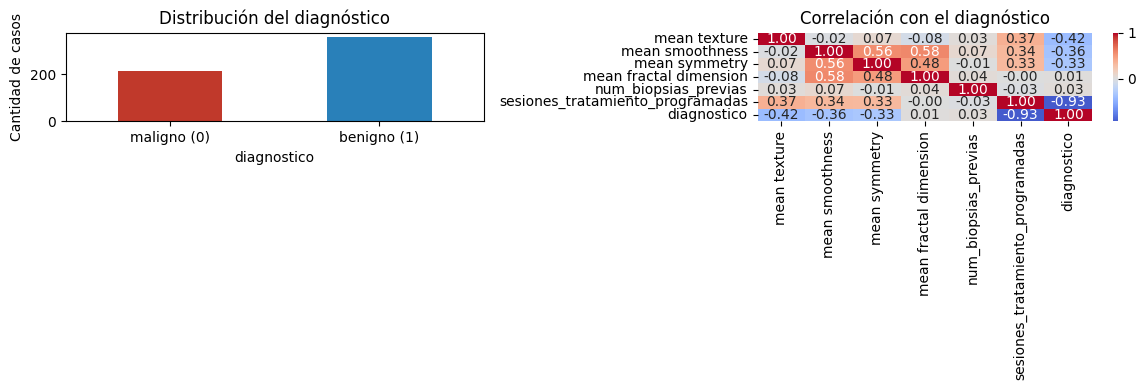

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['diagnostico'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#c0392b', '#2980b9']
)
axes[0].set_xticklabels(['maligno (0)', 'benigno (1)'], rotation=0)
axes[0].set_title('Distribución del diagnóstico')
axes[0].set_ylabel('Cantidad de casos')

columnas_para_correlacion = [
    'mean texture', 'mean smoothness', 'mean symmetry', 'mean fractal dimension',
    'num_biopsias_previas', 'sesiones_tratamiento_programadas', 'diagnostico',
]
corr = df[columnas_para_correlacion].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Correlación con el diagnóstico')

plt.tight_layout()
plt.show()

## 3. Validación de calidad de datos

Un chequeo simple antes de entrenar: que no haya valores infinitos ni nulos colándose en las columnas numéricas.

In [ ]:
def validar_datos(df, columnas):
    """Revisa que las columnas indicadas no tengan nulos ni valores infinitos."""
    problemas = {}
    for col in columnas:
        n_nulos = df[col].isna().sum()
        n_infinitos = np.isinf(df[col]).sum() if np.issubdtype(df[col].dtype, np.number) else 0
        if n_nulos or n_infinitos:
            problemas[col] = {'nulos': int(n_nulos), 'infinitos': int(n_infinitos)}
    return problemas

# --- Diagnóstico del ValueError: ¿dónde nace el valor no finito? ---
df_crudo = cargar_datos()
print("1) Recién cargado: ",
      validar_datos(df_crudo, ['mean texture', 'num_biopsias_previas']))

df_derivado = construir_caracteristicas(df_crudo)
print("2) Con la derivada:",
      validar_datos(df_derivado, COLUMNAS_PREDICTORAS))

malas = df_derivado[~np.isfinite(df_derivado['variabilidad_por_biopsia'])]
print("3) Filas no finitas:", len(malas))
print(malas['num_biopsias_previas'].value_counts())



1) Recién cargado:  {}
2) Con la derivada: {'variabilidad_por_biopsia': {'nulos': 0, 'infinitos': 140}}
3) Filas no finitas: 140
num_biopsias_previas
0    140
Name: count, dtype: int64


## 4. Ingeniería de características

A partir de la textura promedio y del número de biopsias previas, construimos un indicador de variabilidad por biopsia — mientras más biopsias previas tenga la paciente, más se "diluye" la variabilidad reportada.

In [ ]:
def construir_caracteristicas(df):
    """Agrega una métrica derivada de variabilidad de textura por biopsia previa."""
    df = df.copy()
    df['variabilidad_por_biopsia'] = df['mean texture'] / df['num_biopsias_previas']
    return df


df_features = construir_caracteristicas(df)
df_features[['mean texture', 'num_biopsias_previas', 'variabilidad_por_biopsia']].head(10)

,mean texture,num_biopsias_previas,variabilidad_por_biopsia
0,10.38,2,5.190000
1,17.77,3,5.923333
2,21.25,0,inf
3,20.38,2,10.190000
4,14.34,2,7.170000
5,15.70,3,5.233333
6,19.98,0,inf
7,20.83,0,inf
8,21.82,2,10.910000
9,24.04,1,24.040000


### Distribución de la característica nueva

Así se ve la variable recién construida. Vale la pena revisar si su forma tiene sentido.

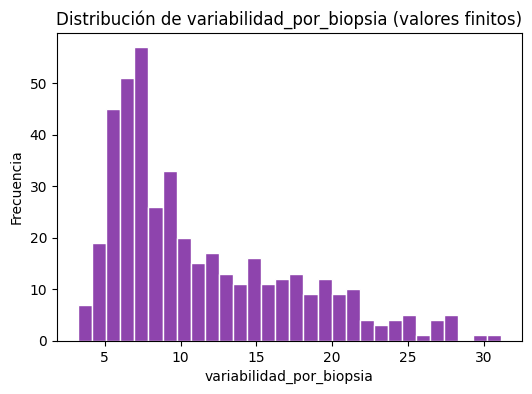

Valores no finitos (inf/NaN) en la columna: 135 de 569


In [ ]:
valores_finitos = df_features['variabilidad_por_biopsia'].replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(6, 4))
plt.hist(valores_finitos.dropna(), bins=30, color='#8e44ad', edgecolor='white')
plt.title('Distribución de variabilidad_por_biopsia (valores finitos)')
plt.xlabel('variabilidad_por_biopsia')
plt.ylabel('Frecuencia')
plt.show()

print(f"Valores no finitos (inf/NaN) en la columna: "
      f"{(~np.isfinite(df_features['variabilidad_por_biopsia'])).sum()} de {len(df_features)}")

## 5. Entrenamiento del modelo

Usamos regresión logística — el mismo clasificador que ya conoces — sobre un subconjunto de columnas clínicas y de imagen.

In [ ]:
COLUMNAS_PREDICTORAS = [
    'mean texture', 'mean smoothness', 'mean symmetry', 'mean fractal dimension',
    'texture error', 'smoothness error', 'symmetry error',
    'variabilidad_por_biopsia', 'num_biopsias_previas',
    'sesiones_tratamiento_programadas',
]


def entrenar_modelo(df, usar_class_weight=False):
    """Entrena un clasificador de regresión logística y devuelve el modelo y sus métricas."""
    X = df[COLUMNAS_PREDICTORAS]
    y = df['diagnostico']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE
    )

    kwargs = {'max_iter': 5000}
    if usar_class_weight:
        kwargs['class_weight'] = 'balanced'

    modelo = LogisticRegression(**kwargs)
    modelo.fit(X_train, y_train)

    acc_train = accuracy_score(y_train, modelo.predict(X_train))
    acc_test = accuracy_score(y_test, modelo.predict(X_test))
    return modelo, acc_train, acc_test

## 6. Ejecutar el pipeline completo

Esto es lo que corre en producción: carga los datos, construye las características y entrena el modelo.

In [ ]:
df = cargar_datos()
df = construir_caracteristicas(df)
modelo, acc_train, acc_test = entrenar_modelo(df)
print(f"Accuracy en entrenamiento: {acc_train:.4f}")
print(f"Accuracy en prueba:        {acc_test:.4f}")

ValueError: Input X contains infinity or a value too large for dtype('float64').

### Peso de cada variable en el modelo

En regresión logística, cada coeficiente indica cuánto empuja esa variable hacia "benigno" o hacia "maligno". Una variable con un peso muchísimo mayor que las demás merece una segunda mirada.

In [ ]:
coeficientes = pd.Series(modelo.coef_[0], index=COLUMNAS_PREDICTORAS).sort_values()

plt.figure(figsize=(7, 5))
colores = ['#c0392b' if v < 0 else '#2980b9' for v in coeficientes]
coeficientes.plot(kind='barh', color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes de la regresión logística')
plt.xlabel('Peso (negativo empuja hacia maligno, positivo hacia benigno)')
plt.tight_layout()
plt.show()

## 7. Guardar el modelo entrenado

El equipo de infraestructura toma este archivo y lo despliega tal cual — así que necesita quedar en un estado entrenado y correcto.

In [ ]:
def guardar_modelo(modelo, ruta="modelo_biopsias.joblib"):
    """Serializa el modelo entrenado para que el servicio de inferencia lo cargue."""
    joblib.dump(modelo, ruta)
    print(f"Modelo guardado en: {ruta}")


guardar_modelo(modelo)

## 8. Predecir un caso nuevo

Así es como el equipo clínico piensa usar la app: le pasan las mediciones de una paciente nueva y el modelo devuelve una predicción.

In [ ]:
def predecir_caso(modelo, caso: dict):
    """Predice el diagnóstico para una paciente nueva a partir de un diccionario de mediciones."""
    entrada = pd.DataFrame([caso])[COLUMNAS_PREDICTORAS]
    pred = modelo.predict(entrada)[0]
    return 'benigno' if pred == 1 else 'maligno'


caso_nuevo = {
    'mean texture': 18.2,
    'mean smoothness': 0.095,
    'mean symmetry': 0.18,
    'mean fractal dimension': 0.062,
    'texture error': 1.1,
    'smoothness error': 0.006,
    'symmetry error': 0.02,
    'variabilidad_por_biopsia': 18.2,
    'num_biopsias_previas': 1,
    'sesiones_tratamiento_programadas': 0,
}

predecir_caso(modelo, caso_nuevo)